# Stochastic Gradient Descent for 3D

We will run stochastic gradient descent in the same way as the 2D case. The fabrication imperfections are the same aswell. 

- etch depth (the partial etch goes too far down) $\sim\mathcal{N}(0,5nm)$
- Ovet/underetched (the teeth are too large or small) $\sim\mathcal{N}(0,5nm)$

In [5]:
import autograd.numpy as np 
import matplotlib.pyplot as plt

import tidy3d as td
import tidy3d.web as web
td.config.logging_level = "ERROR"

import pickle

from main import (make_sim, get_coupling_efficiency, projection_builder, run_adam,
                    R, r0_extra, N_teeth, wl_range)


Define the function to load from history

In [6]:
# define the load function to get the initial parameters
def load_history(filename):
    with open(filename, "rb") as f:
        file = pickle.load(f)
    return file

Now set up the random noise and objective function

In [7]:
# set up random number generator
sigmas = [.005,.005]
rng = np.random.default_rng(seed=42)

# define the objective function
def objective(params,projection=None):
    params_proj = projection(params)
    samples = rng.standard_normal(size=(len(sigmas))) * sigmas
    
    widths = params_proj[:-3]
    r0 = params_proj[N_teeth*2+2]
    etch_depth = params_proj[N_teeth*2+3] + samples[0]
    to_substrate = params_proj[N_teeth*2+4]
    
    sim = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, dilation=samples[1], include_field_monitor=False)
    sim_data = web.run(sim, task_name="GC4um_3D_stochastic_opt", verbose=False, path="data/tidy3d_output/tmp.hdf5")
    coupling_efficiency = get_coupling_efficiency(sim_data)
    return np.mean(coupling_efficiency)

Run the optimization, same set up as the non-stochastic case since all the change is within the objective fucnction

In [8]:
# load the previous parameters
data = load_history("../GC_4um_2D/data/opt/history_stochastic.pkl")
params = data['history']['params'][-1]

# make the grating structure
widths = params[:-3]
r0 = params[-3] + r0_extra # need to add the taper length
etch_depth = params[-2]
to_substrate = params[-3]

# re-pack the parameters in an autograd array 
params = np.concatenate([widths, [r0], [etch_depth], [to_substrate]])

# define the projection for enforcing constraints
project, inverse_project = projection_builder()

# run the optimization
history, opt_state = run_adam(params, project, inverse_project, objective, num_steps=50, learning_rate=0.01, verbose=True)

step = 1
	J = 4.387e-01
	grad_norm = 7.7340e-01
step = 2
	J = 4.367e-01
	grad_norm = 6.4561e-01
	angle = 40.96350049971233
step = 3
	J = 4.367e-01
	grad_norm = 6.9807e-01
	angle = 22.552140240074866
step = 4
	J = 4.766e-01
	grad_norm = 6.0931e-01
	angle = 15.362678472994729
step = 5
	J = 4.937e-01
	grad_norm = 5.6779e-01
	angle = 4.661210832070536
step = 6
	J = 4.870e-01
	grad_norm = 6.0933e-01
	angle = 19.08549509110983
step = 7
	J = 4.582e-01
	grad_norm = 7.0588e-01
	angle = 16.703931055146757
step = 8
	J = 5.320e-01
	grad_norm = 4.9163e-01
	angle = 39.69375885116381
step = 9
	J = 5.405e-01
	grad_norm = 4.7026e-01
	angle = 1.0976093561189635
step = 10
	J = 5.467e-01
	grad_norm = 4.8368e-01
	angle = 13.506163227295923
step = 11
	J = 5.447e-01
	grad_norm = 5.0603e-01
	angle = 13.43635673076129
step = 12
	J = 5.708e-01
	grad_norm = 4.2217e-01
	angle = 26.306920226962287
step = 13
	J = 5.486e-01
	grad_norm = 5.6090e-01
	angle = 39.28713602708252
step = 14
	J = 5.648e-01
	grad_norm = 5.06

In [9]:
# save history and opt state in a pickle file
with open('data/3d_opt/history_stochastic.pkl', 'wb') as f:
    pickle.dump({'history': history, 'opt_state': opt_state}, f)

# Analysis 

Now we analyze the results of the optimization

In [10]:
# define the initial simulation
sim_initial = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, include_field_monitor=True)

# pull out the final parameters
widths_final = history["params"][-1][:-3]
r0_final = history["params"][-1][-3]
etch_depth_final = history["params"][-1][-2]
to_substrate_final = history["params"][-1][-1]

#define the final simulation 
sim_final = make_sim(widths_final, r0=r0_final, etch_depth=etch_depth_final, to_substrate=to_substrate_final, include_field_monitor=True)

#run the two simulations 
sim_data_initial = web.run(sim_initial, task_name="GC4um_3D_initial_opt", verbose=False, path="data/tidy3d_output/tmp.hdf5")
sim_data_final = web.run(sim_final, task_name="GC4um_3D_final_opt", verbose=False, path="data/tidy3d_output/tmp.hdf5")

#compute the coupling efficiencies 
ce_initial = get_coupling_efficiency(sim_data_initial)
ce_final = get_coupling_efficiency(sim_data_final)

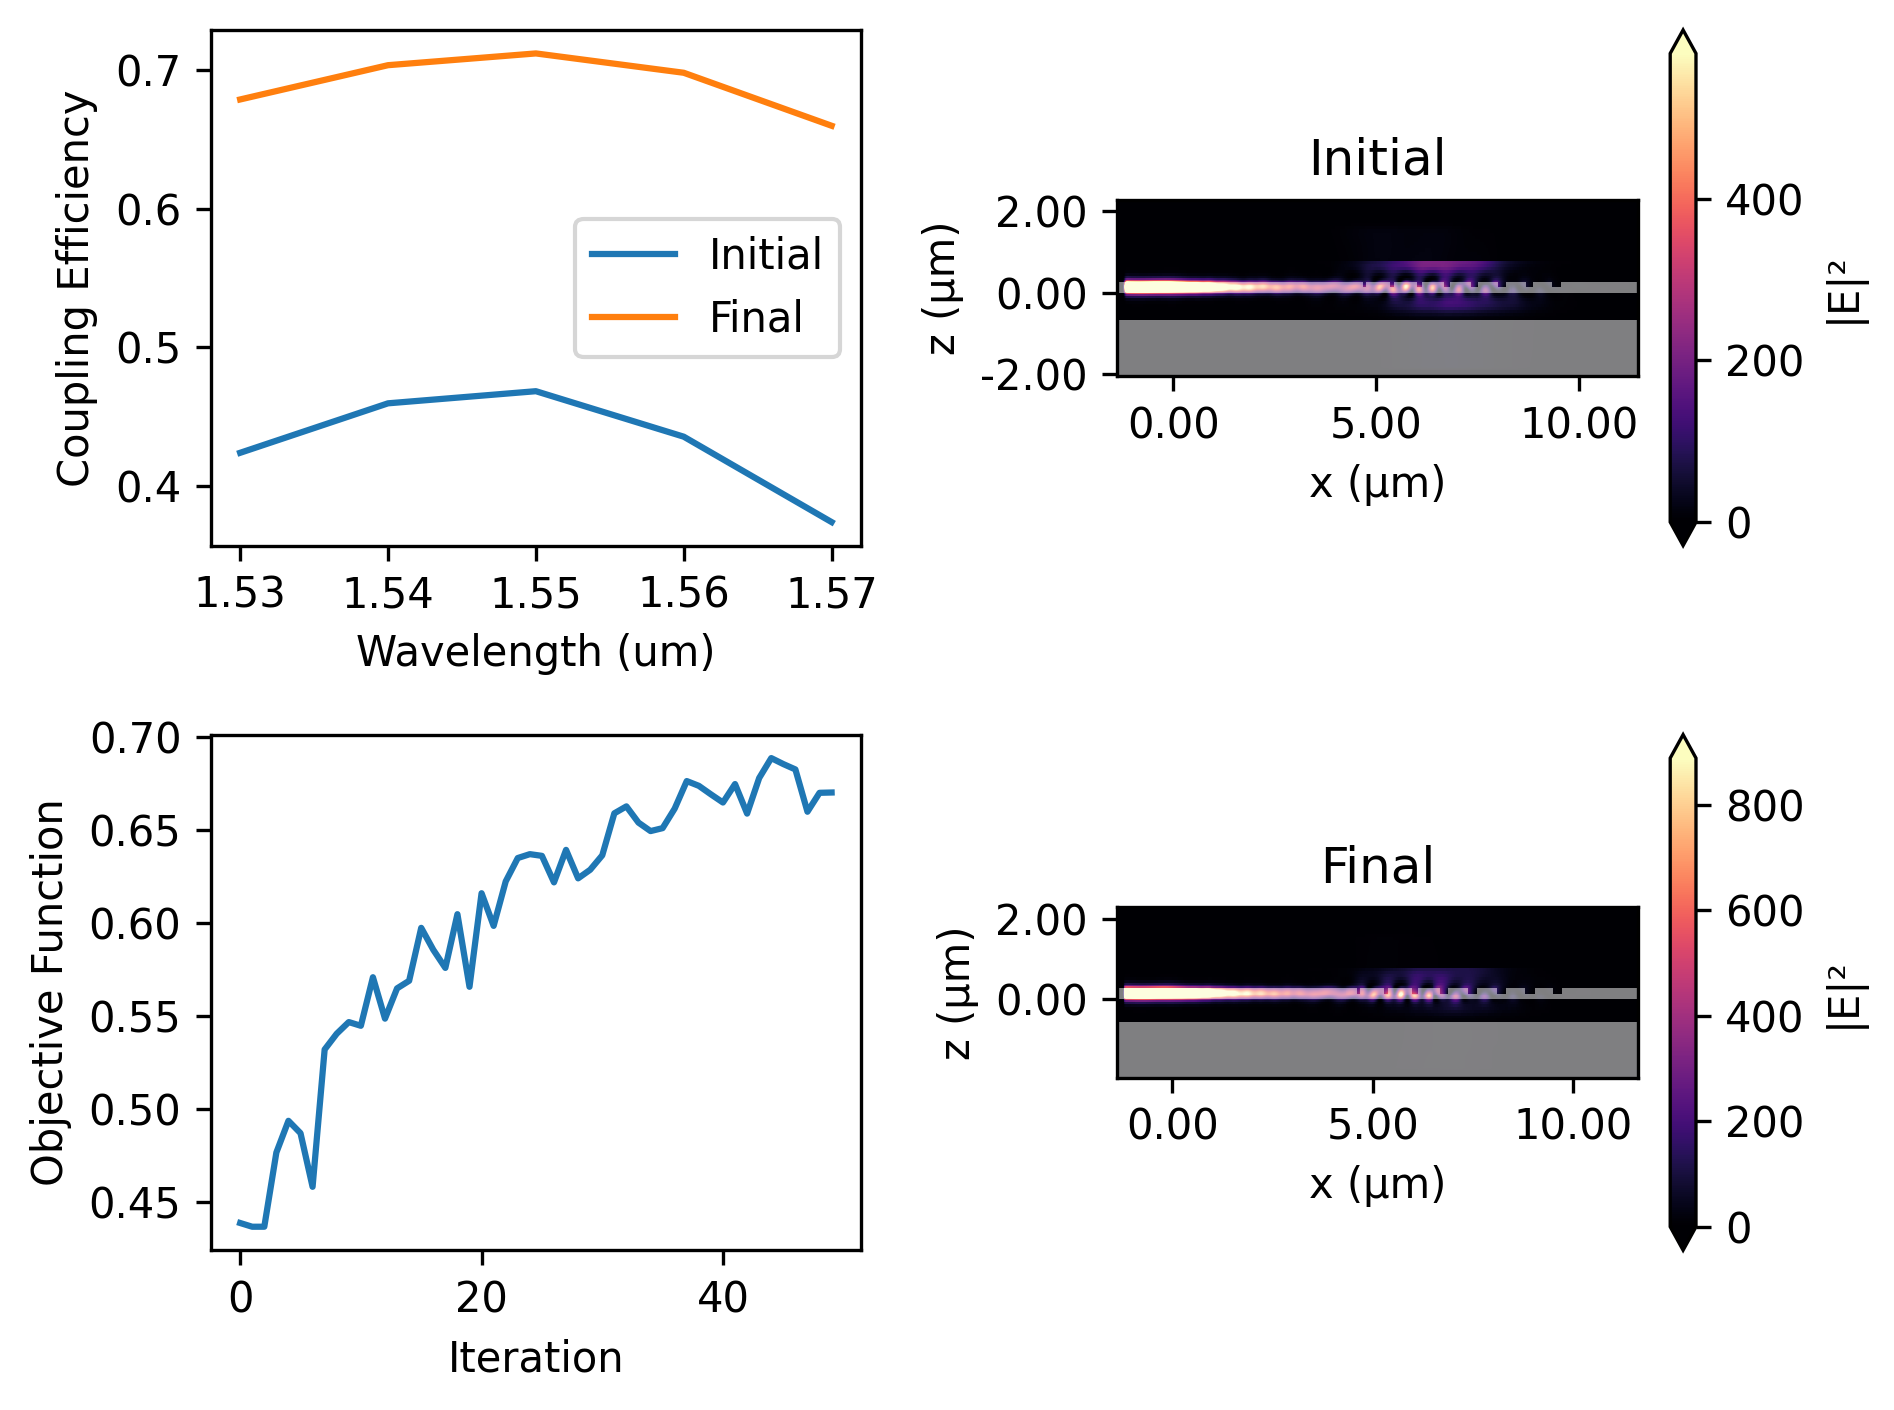

In [11]:
fig,ax = plt.subplots(2,2,dpi=300)

#plot the coupling efficiencies 
ax[0,0].plot(wl_range, ce_initial,label="Initial")
ax[0,0].plot(wl_range, ce_final,label="Final")
ax[0,0].set_xlabel("Wavelength (um)")
ax[0,0].set_ylabel("Coupling Efficiency")
ax[0,0].legend()

#plot the field monitors 
sim_data_initial.plot_field("field", "E", "abs^2", y=0, ax=ax[0,1],eps_alpha=0.5)
ax[0,1].set_title("Initial")
sim_data_final.plot_field("field", "E", "abs^2", y=0, ax=ax[1,1],eps_alpha=0.5)
ax[1,1].set_title("Final")

# plot the change in the objective function 
ax[1,0].plot(history["J"])
ax[1,0].set_xlabel("Iteration")
ax[1,0].set_ylabel("Objective Function")

plt.tight_layout()
plt.show()